# 06 - Linear Filtering of Color Images

Filtering complete RGB channels is compared with filtering only the luminance-related Lab channel. The comparison identifies color and edge changes introduced by each strategy.

In [1]:
from pathlib import Path
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def find_course_root() -> Path:
    """Locate the cloned course repository without a machine-specific path."""
    candidates = []
    configured = os.environ.get("VISION_ROBOTICA_REPO")
    if configured:
        candidates.append(Path(configured).expanduser())
    current = Path.cwd().resolve()
    candidates.extend([current, *current.parents])
    for candidate in candidates:
        if (candidate / "imagenes").is_dir() and (candidate / "requirements.txt").is_file():
            return candidate
    raise FileNotFoundError(
        "Course repository not found. Run the notebook from the cloned repository root "
        "or define VISION_ROBOTICA_REPO."
    )

ROOT = find_course_root()
COURSE_IMAGES = ROOT / "imagenes"
STUDENT_IMAGES = ROOT / "student_work" / "imagenes"
STUDENT_IMAGES.mkdir(parents=True, exist_ok=True)

def load_rgb(filename: str) -> np.ndarray:
    path = COURSE_IMAGES / filename
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Official course image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Course root: {ROOT}")
print(f"Official images: {COURSE_IMAGES}")
print(f"Student images: {STUDENT_IMAGES}")

Course root: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica
Official images: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica\imagenes
Student images: C:\Users\20808\Documents\Repositorios\Vision_en_Robotica\student_work\imagenes


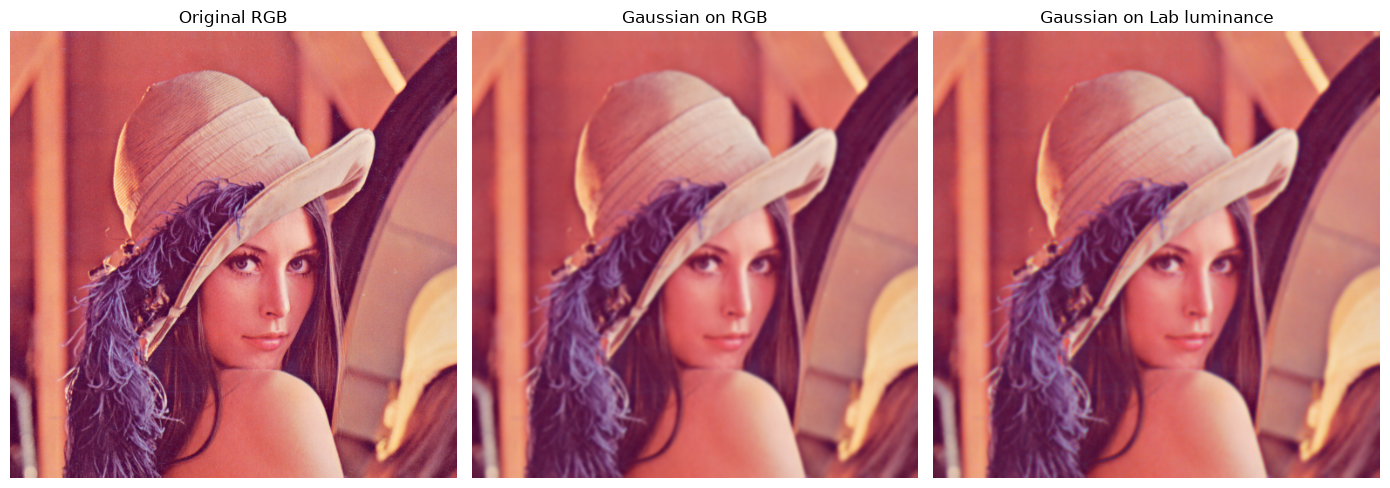

In [2]:
image_rgb = load_rgb("lenna.png")
kernel_size, sigma = 7, 1.5

rgb_filtered = cv2.GaussianBlur(image_rgb, (kernel_size, kernel_size), sigmaX=sigma)

lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
L_channel, a_channel, b_channel = cv2.split(lab)
L_filtered = cv2.GaussianBlur(L_channel, (kernel_size, kernel_size), sigmaX=sigma)
luminance_filtered = cv2.cvtColor(cv2.merge((L_filtered, a_channel, b_channel)), cv2.COLOR_LAB2RGB)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for axis, image, title in zip(
    axes,
    [image_rgb, rgb_filtered, luminance_filtered],
    ["Original RGB", "Gaussian on RGB", "Gaussian on Lab luminance"],
):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()

In [3]:
rgb_difference = cv2.absdiff(image_rgb, rgb_filtered)
luminance_difference = cv2.absdiff(image_rgb, luminance_filtered)

def mean_delta_e76(reference_rgb: np.ndarray, test_rgb: np.ndarray) -> float:
    reference = cv2.cvtColor(reference_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    test = cv2.cvtColor(test_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    return float(np.mean(np.linalg.norm(reference - test, axis=2)))

print(f"Mean absolute RGB change, RGB filtering: {rgb_difference.mean():.3f}")
print(f"Mean absolute RGB change, luminance filtering: {luminance_difference.mean():.3f}")
print(f"Mean OpenCV-Lab distance, RGB filtering: {mean_delta_e76(image_rgb, rgb_filtered):.3f}")
print(f"Mean OpenCV-Lab distance, luminance filtering: {mean_delta_e76(image_rgb, luminance_filtered):.3f}")

Mean absolute RGB change, RGB filtering: 4.951
Mean absolute RGB change, luminance filtering: 4.400
Mean OpenCV-Lab distance, RGB filtering: 5.800
Mean OpenCV-Lab distance, luminance filtering: 4.283


## Interpretation

Filtering only luminance-related information can reduce direct modification of chromatic channels, but conversion and clipping can still change RGB values. The preferred strategy depends on whether the downstream task uses color boundaries, luminance texture, or both.